# 📉 Sesión 3 — Severidad en la práctica: el ramo y las transformaciones
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 1 · Severidad** · **Herramienta:** Python
**Proyecto:** módulo de severidad de la nota técnica

---

> **Objetivo:** ver que la severidad que modelas **no es la cruda**. El ramo la ubica y la póliza la
> transforma (deducible, límite, coaseguro). Aprenderemos a aplicar esas transformaciones, a
> reconocer **truncamiento y censura**, y por qué ignorarlos **sesga el ajuste** y la prima.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**

## Contenido
1. [Entorno](#1)
2. [La severidad cambia entre ramos](#2)
3. [La severidad cruda y su ajuste](#3)
4. [Deducible: aplicar la transformación](#4)
5. [El sesgo de ignorar el truncamiento](#5)
6. [Límite y suma asegurada (censura)](#6)
7. [El efecto en la prima](#7)
8. [Cierre → Práctica A1](#8)

---

---
<a id='1'></a>
## 1. Entorno

In [1]:
# ─── Entorno ────────────────────────────────────────────────────────────────
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

np.random.seed(7)
plt.rcParams["figure.figsize"] = (9, 4.2)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. La severidad cambia entre ramos

Un siniestro de auto no vive en la misma escala que uno marítimo. Antes de simular o ajustar,
conviene saber **en qué rango** se mueve el ramo.

In [2]:
# ─── Rango típico por ramo (mediana, p95, p99) ─────────────────────────────
ramos = {
    "Autos":       stats.lognorm(s=0.7, scale=60),
    "Incendio":    stats.lognorm(s=0.9, scale=400),
    "Resp. civil": stats.lognorm(s=1.2, scale=250),
    "Marítimo":    stats.lognorm(s=0.8, scale=1200),
}
filas = []
for nom, d in ramos.items():
    filas.append({"Ramo": nom, "mediana": d.ppf(0.50), "p95": d.ppf(0.95), "p99": d.ppf(0.99)})
tabla_ramos = pd.DataFrame(filas).set_index("Ramo").round(0)
print(tabla_ramos.to_string())
print("\nMismo tipo de distribución, escalas y colas muy distintas: el ramo fija el rango.")

             mediana     p95     p99
Ramo                                
Autos           60.0   190.0   306.0
Incendio       400.0  1758.0  3246.0
Resp. civil    250.0  1800.0  4077.0
Marítimo      1200.0  4474.0  7717.0

Mismo tipo de distribución, escalas y colas muy distintas: el ramo fija el rango.


### ✏️ Ejercicio 1 — el rango de un ramo

1. Elige un ramo de la tabla y calcula qué proporción de siniestros supera **el doble de su p95**.
2. ¿En qué intervalo (aprox. p1 a p99) tiene sentido simular montos para ese ramo?

In [6]:
# Tu código aquí 👇
ramo_nombre = "Autos"
d = ramos[ramo_nombre]
p95 = d.ppf(0.95)
prop_supera_doble_p95 = d.sf(2 * p95)
p1 = d.ppf(0.01)
p99 = d.ppf(0.99)
#Punto 1
print(f"--- Ramo: {ramo_nombre} ---")
print(f"1. Proporción de siniestros que supera 2*p95 ({2 * p95:.1f}): {prop_supera_doble_p95 * 100:.2f}%")
print("Solo el 0.42% de los siniestros supera el doble del p95 (379.5). Esto demuestra que en Autos los reclamos casi nunca duplican la severidad de un evento severo habitual.")
#Respuesta al punto 2
print(f"2. Intervalo sensato para simular (p1 a p99): [{p1:.1f}, {p99:.1f}]")
print("El rango ideal para simular es de 11.8 a 305.8 (p1 a p99). ")
# Pista: d = ramos["Autos"];  d.sf(2*d.ppf(0.95)) ;  d.ppf(0.01), d.ppf(0.99)


--- Ramo: Autos ---
1. Proporción de siniestros que supera 2*p95 (379.5): 0.42%
Solo el 0.42% de los siniestros supera el doble del p95 (379.5). Esto demuestra que en Autos los reclamos casi nunca duplican la severidad de un evento severo habitual.
2. Intervalo sensato para simular (p1 a p99): [11.8, 305.8]
El rango ideal para simular es de 11.8 a 305.8 (p1 a p99). 


---
<a id='3'></a>
## 3. La severidad cruda y su ajuste

Generamos una muestra de severidad **cruda** (ground-up: el monto real del daño, sin póliza de por
medio) y ajustamos una lognormal como base.

In [7]:
# ─── Severidad cruda (ground-up) ───────────────────────────────────────────
real = stats.lognorm(s=0.9, scale=180)      # la "verdad" que normalmente NO conocemos
x = real.rvs(5_000)

pr_real = stats.lognorm.fit(x, floc=0)
print(f"Ajuste a datos CRUDOS   → s={pr_real[0]:.3f}, scale={pr_real[2]:.1f}")
print(f"Media ajustada           → {stats.lognorm(*pr_real).mean():,.1f}")
print(f"Media empírica           → {x.mean():,.1f}")

Ajuste a datos CRUDOS   → s=0.895, scale=176.4
Media ajustada           → 263.5
Media empírica           → 262.4


---
<a id='4'></a>
## 4. Deducible: aplicar la transformación

Con un deducible $d$, la aseguradora paga $Y=\max(X-d,0)$. Hay dos situaciones distintas:

- **Censura:** sabes que hubo siniestro, pero muchos pagan 0 (los que no superan $d$).
- **Truncamiento:** si los siniestros bajo $d$ **no se reportan**, ni siquiera los ves.

Deducible d = 200
Siniestros totales        : 5,000
Pagan 0 (por debajo de d) : 55.4%   ← censura
Siniestros que 've' la aseguradora si hay truncamiento: 2,232


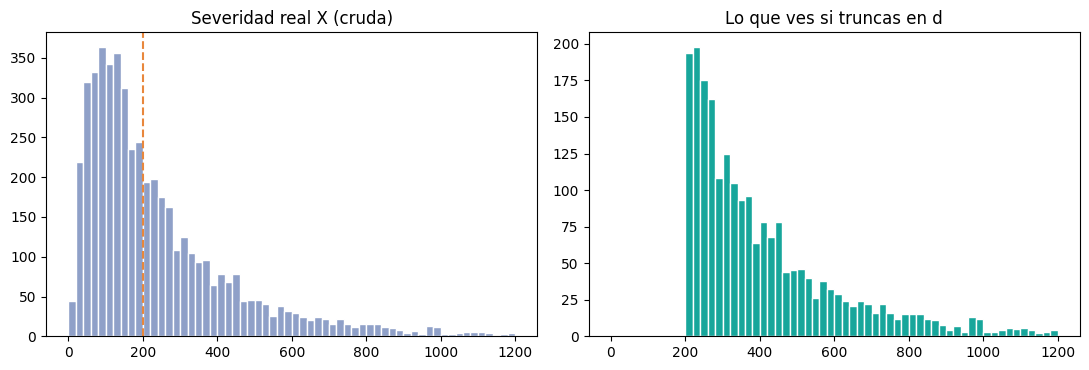

In [8]:
# ─── Aplicar un deducible d ─────────────────────────────────────────────────
d = 200
pago      = np.maximum(x - d, 0)          # lo que paga la aseguradora
observado = x[x > d]                        # lo que ves si los < d NO se reportan (truncado)

print(f"Deducible d = {d}")
print(f"Siniestros totales        : {len(x):,}")
print(f"Pagan 0 (por debajo de d) : {(x <= d).mean():.1%}   ← censura")
print(f"Siniestros que 've' la aseguradora si hay truncamiento: {len(observado):,}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(x, bins=60, range=(0, 1200), color="#8FA0C8", edgecolor="white"); ax[0].axvline(d, color="#E8873C", ls="--")
ax[0].set_title("Severidad real X (cruda)")
ax[1].hist(observado, bins=60, range=(0, 1200), color="#17A69B", edgecolor="white")
ax[1].set_title("Lo que ves si truncas en d")
plt.tight_layout(); plt.show()

### ✏️ Ejercicio 2 — censura y truncamiento

Con **otro** deducible (por ejemplo $d=100$):
1. ¿Qué porcentaje de siniestros paga 0 (censura)?
2. ¿Cuántos siniestros desaparecen de tu muestra si hay truncamiento?

In [9]:
# Tu código aquí 👇
# Pista: (x <= 100).mean()  ;  (x > 100).sum()
d=100
pct_censura= (x <= d).mean() * 100
desaparecen = (x <= d).sum()
que_quedan = (x > d).sum()

print(f"--- Deducible d = {d} ---")
print(f"1. Porcentaje de siniestros que paga 0 (censura): {pct_censura:.2f}%")
print(f"2. Siniestros que desaparecen por truncamiento: {desaparecen:,} de {len(x):,} (quedan {que_quedan:,})\n")

print(f"1. Al bajar el deducible a 100, la censura disminuye a aproximadamente {pct_censura:.2f}%, ya que más siniestros logran superarlo.")
print(f"2. Si hay truncamiento, desaparecen exactamente {desaparecen:,} siniestros de la muestra original porque la aseguradora nunca se entera de reclamos menores o iguales a {d}.")



--- Deducible d = 100 ---
1. Porcentaje de siniestros que paga 0 (censura): 25.58%
2. Siniestros que desaparecen por truncamiento: 1,279 de 5,000 (quedan 3,721)

1. Al bajar el deducible a 100, la censura disminuye a aproximadamente 25.58%, ya que más siniestros logran superarlo.
2. Si hay truncamiento, desaparecen exactamente 1,279 siniestros de la muestra original porque la aseguradora nunca se entera de reclamos menores o iguales a 100.


---
<a id='5'></a>
## 5. El sesgo de ignorar el truncamiento

Aquí está la lección. Si ajustas una lognormal a los datos **truncados** como si fueran crudos,
el ajuste sale **sesgado**. La forma correcta usa la densidad **condicional** $f(x)/S(d)$.

                           s     scale       media
Verdad                 0.900     180.0       269.9
Ingenuo (sesgado)      0.642     260.3       319.8
Truncado (correcto)    0.886     176.4       261.0


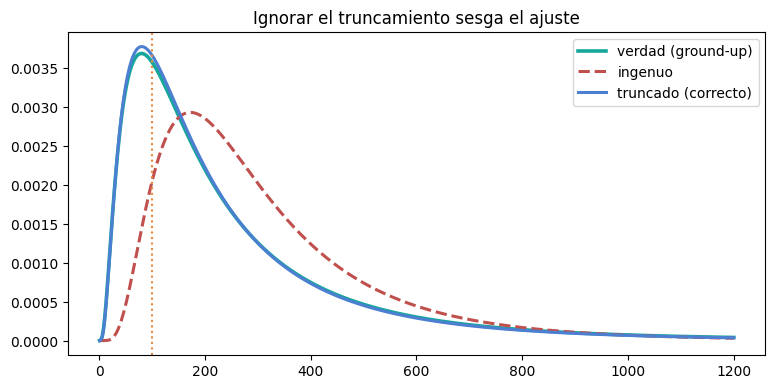

In [10]:
# ─── Ajuste ingenuo vs. ajuste truncado (correcto) ─────────────────────────
obs = x[x > d]                                  # datos truncados por el deducible

# (a) INGENUO: ajusta como si fueran crudos
pr_naive = stats.lognorm.fit(obs, floc=0)

# (b) CORRECTO: máxima verosimilitud TRUNCADA  → resta n·log S(d)
def nll_trunc(params, datos, d):
    s, scale = params
    if s <= 0 or scale <= 0:
        return np.inf
    dist = stats.lognorm(s, scale=scale)
    return -(np.sum(dist.logpdf(datos)) - len(datos) * np.log(dist.sf(d)))

res = minimize(nll_trunc, x0=[1.0, np.median(obs)], args=(obs, d), method="Nelder-Mead")
s_c, scale_c = res.x

print(f"{'':20}{'s':>8}{'scale':>10}{'media':>12}")
print(f"{'Verdad':20}{0.9:>8.3f}{180:>10.1f}{real.mean():>12,.1f}")
print(f"{'Ingenuo (sesgado)':20}{pr_naive[0]:>8.3f}{pr_naive[2]:>10.1f}{stats.lognorm(*pr_naive).mean():>12,.1f}")
print(f"{'Truncado (correcto)':20}{s_c:>8.3f}{scale_c:>10.1f}{stats.lognorm(s_c, scale=scale_c).mean():>12,.1f}")

xx = np.linspace(1, 1200, 500)
plt.plot(xx, real.pdf(xx), color="#17A69B", lw=2.6, label="verdad (ground-up)")
plt.plot(xx, stats.lognorm(*pr_naive).pdf(xx), color="#C0504D", lw=2.2, ls="--", label="ingenuo")
plt.plot(xx, stats.lognorm(s_c, scale=scale_c).pdf(xx), color="#4C7FD1", lw=2.2, label="truncado (correcto)")
plt.axvline(d, color="#E8873C", ls=":"); plt.title("Ignorar el truncamiento sesga el ajuste")
plt.legend(); plt.show()

### ✏️ Ejercicio 3 — mide el sesgo

1. Repite el ajuste **ingenuo** con un deducible más grande, $d=300$.
2. Calcula el error relativo de su media contra la verdad: `(media_ingenua - real.mean())/real.mean()`.
3. ¿El sesgo crece o baja al subir el deducible? ¿Por qué?

In [16]:
# Tu código aquí 👇
# Pista: obs2 = x[x > 300];  pr2 = stats.lognorm.fit(obs2, floc=0)
d_nuevo = 300
obs2 = x[x > d_nuevo]
pr2 = stats.lognorm.fit(obs2, floc=0)

media_real = real.mean()
media_ingenua = stats.lognorm(*pr2).mean()

error_relativo = (media_ingenua - media_real) / media_real

print(f"Ajuste Ingenuo con d = {d_nuevo} ")
print(f"Media real             : {media_real:.1f}")
print(f"Media ingenua          : {media_ingenua:.1f}")
print(f"Error relativo         : {error_relativo * 100:.2f}%\n")


print(f"Con d = 300, la media ingenua es {media_ingenua:.1f}, lo que representa un error relativo del {error_relativo * 100:.2f}%.")
#Respuesta al punto 3
print("El sesgo crece al subir el deducible. Al truncar un valor mas alto, se ignora una porcion mas grande de la cola izquierda (siniestros pequeños), haciendo que el modelo ingenuo crea que la severidad promedio de la cartera es mucho mayor de lo que realmente es.")


Ajuste Ingenuo con d = 300 
Media real             : 269.9
Media ingenua          : 567.9
Error relativo         : 110.42%

Con d = 300, la media ingenua es 567.9, lo que representa un error relativo del 110.42%.
El sesgo crece al subir el deducible. Al truncar un valor mas alto, se ignora una porcion mas grande de la cola izquierda (siniestros pequeños), haciendo que el modelo ingenuo crea que la severidad promedio de la cartera es mucho mayor de lo que realmente es.


---
<a id='6'></a>
## 6. Límite y suma asegurada (censura por la derecha)

Con un límite (o suma asegurada) $L$, la aseguradora paga $\min(X,L)$: lo que exceda se **amontona**
en $L$. La prima con límite es la **esperanza limitada** $E[\min(X,L)]$.

Límite L = 700
Masa amontonada en L: P(X>L) = 5.9%
E[min(X,L)] empírica : 238.3
E[min(X,L)] modelo   : 242.6
E[X] sin límite      : 262.4   ← la cobertura con límite cuesta menos


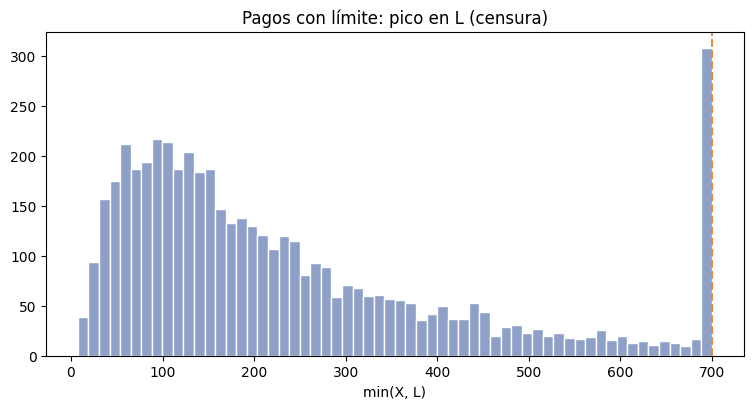

In [17]:
# ─── Aplicar un límite L ────────────────────────────────────────────────────
L = 700
pago_lim = np.minimum(x, L)

masa_en_L = (x > L).mean()
lev_emp   = pago_lim.mean()
lev_mod   = real.expect(lambda t: min(t, L))

print(f"Límite L = {L}")
print(f"Masa amontonada en L: P(X>L) = {masa_en_L:.1%}")
print(f"E[min(X,L)] empírica : {lev_emp:,.1f}")
print(f"E[min(X,L)] modelo   : {lev_mod:,.1f}")
print(f"E[X] sin límite      : {x.mean():,.1f}   ← la cobertura con límite cuesta menos")

plt.hist(pago_lim, bins=60, color="#8FA0C8", edgecolor="white")
plt.axvline(L, color="#E8873C", ls="--"); plt.title("Pagos con límite: pico en L (censura)")
plt.xlabel("min(X, L)"); plt.show()

### ✏️ Ejercicio 4 — la esperanza limitada

1. Calcula $E[\min(X,L)]$ (empírica) para $L=400$ y $L=1000$.
2. ¿Qué fracción de la prima cruda $E[X]$ representa cada una?

In [18]:
# Tu código aquí 👇
# Pista: np.minimum(x, 400).mean()  ;  .../ x.mean()
L1=400
L2=1000
prima_cruda = x.mean()
lev1 = np.minimum(x, L1).mean()
lev2 = np.minimum(x, L2).mean()
frac1 = lev1 / prima_cruda
frac2 = lev2 / prima_cruda

print(f"Prima cruda E[X] sin límite: {prima_cruda:.2f}\n")

print(f"--- Para L = {L1} ---")
print(f"1. E[min(X, {L1})] empírica : {lev1:.2f}")
print(f"2. Fracción de la prima cruda : {frac1 * 100:.1f}%\n")

print(f"--- Para L = {L2} ---")
print(f"1. E[min(X, {L2})] empírica : {lev2:.2f}")
print(f"2. Fracción de la prima cruda : {frac2 * 100:.1f}%\n")


Prima cruda E[X] sin límite: 262.36

--- Para L = 400 ---
1. E[min(X, 400)] empírica : 206.54
2. Fracción de la prima cruda : 78.7%

--- Para L = 1000 ---
1. E[min(X, 1000)] empírica : 249.82
2. Fracción de la prima cruda : 95.2%



---
<a id='7'></a>
## 7. El efecto en la prima

Cada transformación cambia la **prima pura**. La comparamos, empíricamente, sobre la misma cartera.

In [19]:
# ─── Prima pura bajo distintas transformaciones ────────────────────────────
d, L, alpha = 200, 700, 0.8
prima = {
    "Cruda  E[X]":                         x.mean(),
    "Con deducible  E[max(X-d,0)]":        np.maximum(x - d, 0).mean(),
    "Con límite  E[min(X,L)]":             np.minimum(x, L).mean(),
    "Deducible + límite":                  np.minimum(np.maximum(x - d, 0), L - d).mean(),
    "Coaseguro alpha·E[max(X-d,0)]":       alpha * np.maximum(x - d, 0).mean(),
}
for k, v in prima.items():
    print(f"{k:<34} {v:>10,.1f}")
print("\nCada cláusula de la póliza mueve la prima. Por eso hay que modelar la severidad")
print("TRANSFORMADA que corresponde al producto — no la cruda a secas.")

Cruda  E[X]                             262.4
Con deducible  E[max(X-d,0)]            113.8
Con límite  E[min(X,L)]                 238.3
Deducible + límite                       89.8
Coaseguro alpha·E[max(X-d,0)]            91.0

Cada cláusula de la póliza mueve la prima. Por eso hay que modelar la severidad
TRANSFORMADA que corresponde al producto — no la cruda a secas.


### ✏️ Ejercicio 5 — arma tu combinación

1. Elige un deducible, un límite y un coaseguro y calcula la prima pura resultante.
2. Compárala con la prima cruda: ¿cuánto la reduce cada cláusula?

In [23]:
# Tu código aquí 👇
d=150
L=600
alpha=0.85

p_cruda = x.mean()

p_ded = np.maximum(x - d, 0).mean()
p_lim = np.minimum(x, L).mean()
p_coas = alpha * x.mean()

p_comb = alpha * np.minimum(np.maximum(x - d, 0), L - d).mean()
red_ded = (1 - p_ded / p_cruda) * 100
red_lim = (1 - p_lim / p_cruda) * 100
red_coas = (1 - alpha) * 100
red_comb = (1 - p_comb / p_cruda) * 100

print(f"PRIMA CRUDA BASE: {p_cruda:.2f}")

print("EFECTO DE CADA CLÁUSULA INDIVIDUAL")
print(f"1. Solo Deducible (d={d})       : {p_ded:.2f}  (reduce un {red_ded:.1f}%)")
print(f"2. Solo Límite (L={L})           : {p_lim:.2f}  (reduce un {red_lim:.1f}%)")
print(f"3. Solo Coaseguro (alpha={alpha})  : {p_coas:.2f}  (reduce un {red_coas:.1f}%)\n")

print(f"COMBINACIÓN (d={d}, L={L}, alpha={alpha})")
print(f"Prima pura resultante           : {p_comb:.2f}")
print(f"Reducción total acumulada       : {red_comb:.1f}%\n")

print(f"La prima pura resultante combinada es {p_comb:.2f} frente a la cruda de {p_cruda:.2f}.")

PRIMA CRUDA BASE: 262.36
EFECTO DE CADA CLÁUSULA INDIVIDUAL
1. Solo Deducible (d=150)       : 139.14  (reduce un 47.0%)
2. Solo Límite (L=600)           : 231.27  (reduce un 11.8%)
3. Solo Coaseguro (alpha=0.85)  : 223.00  (reduce un 15.0%)

COMBINACIÓN (d=150, L=600, alpha=0.85)
Prima pura resultante           : 91.85
Reducción total acumulada       : 65.0%

La prima pura resultante combinada es 91.85 frente a la cruda de 262.36.


---
<a id='8'></a>
## 8. Cierre → Práctica A1

Ya con criterio, el laboratorio de tu equipo (Práctica A1) es:

1. **Ubica** el rango y la cola típica del ramo de tu equipo.
2. **Ajusta** la severidad con las candidatas de la sesión anterior.
3. **Aplica y visualiza** el efecto de deducible, límite y coaseguro sobre esa severidad.
4. **Reporta** cómo esas transformaciones mueven la prima pura.
5. **Distingue** siempre qué es dato crudo (ground-up) y qué es dato transformado.

> Con esto el ajuste deja de ser “un histograma pelón”: sabes qué modelas y por qué.
> Súbelo a tu carpeta del repositorio en GitHub.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 1 · Sesión 3*

=== 1. RANGO Y COLA DEL RAMO (AUTOS) ===
Rango sensato de simulación (p1 a p99): [11.8, 305.8]
Proporción de siniestros que supera 2*p95 (379.5): 0.42%

=== 2. TABLA DE AIC DE DISTRIBUCIONES CANDIDATAS ===
Distribución     AIC
   Lognormal 64820.6
        Fisk 64896.9
       Gamma 65383.2
     Weibull 65578.0
      Pareto 73244.6




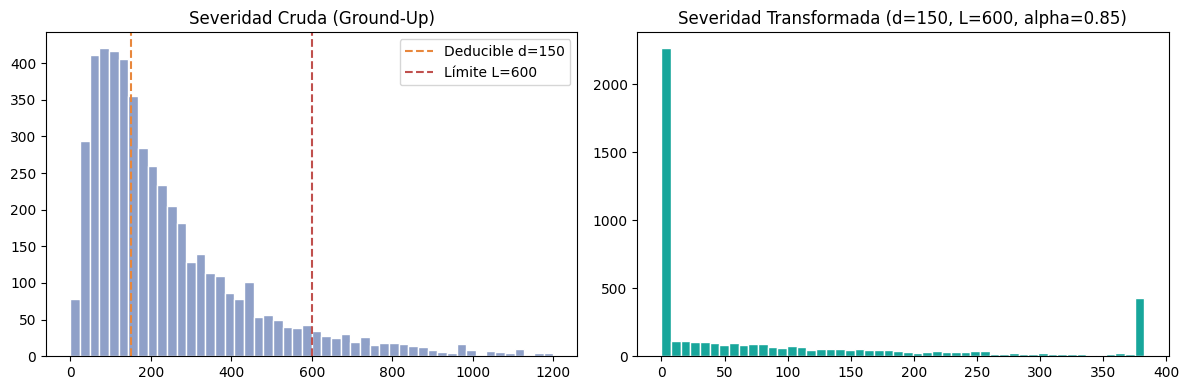

=== 4. REPORTE DE MOVIMIENTO DE PRIMA PURA ===
           Cláusula / Transformación  Prima Pura % Reducción
                    Prima Cruda E[X]      262.36        0.0%
              Solo Deducible (d=150)      139.14       47.0%
                 Solo Límite (L=600)      231.27       11.8%
Combinada (d=150, L=600, alpha=0.85)       91.85       65.0%


=== 5. DISTINCIÓN CONCEPTUAL Y DISCUSIÓN ===
Dato Crudo (Ground-Up): Muestra el costo real total del daño sin importar la existencia de la póliza.
Dato Transformado: Es el desembolso neto efectuado por la aseguradora tras aplicar el deducible, límite y coaseguro.
Advertencia de Sesgo: Ajustar modelos sobre datos truncados por deducible (sin usar máxima verosimilitud condicional) sobrestima severamente la media real de la cartera, pues elimina los siniestros pequeños y simula una severidad artificialmente alta.


In [26]:
#1
ramo_nombre = "Autos"
d_ramo = ramos[ramo_nombre]

p1_r = d_ramo.ppf(0.01)
p95_r = d_ramo.ppf(0.95)
p99_r = d_ramo.ppf(0.99)
prop_doble_p95 = d_ramo.sf(2 * p95_r)

print(f"=== 1. RANGO Y COLA DEL RAMO ({ramo_nombre.upper()}) ===")
print(f"Rango sensato de simulación (p1 a p99): [{p1_r:.1f}, {p99_r:.1f}]")
print(f"Proporción de siniestros que supera 2*p95 ({2*p95_r:.1f}): {prop_doble_p95 * 100:.2f}%\n")

#2
candidatas = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto,
    "Fisk": stats.fisk
}

ajustes = {}
filas_aic = []

for nom, dist in candidatas.items():
    pr = dist.fit(x, floc=0)
    ajustes[nom] = (dist, pr)
    log_lik = np.sum(dist.logpdf(x, *pr))
    k = len(pr)
    aic_val = 2 * k - 2 * log_lik
    filas_aic.append({"Distribución": nom, "AIC": round(aic_val, 1)})

tabla_aic = pd.DataFrame(filas_aic).sort_values("AIC").reset_index(drop=True)

print("=== 2. TABLA DE AIC DE DISTRIBUCIONES CANDIDATAS ===")
print(tabla_aic.to_string(index=False))
print("\n")

#3
d_p=150
L_p=600
alpha_p=0.85

pago_transformado = alpha_p * np.minimum(np.maximum(x - d_p, 0), L_p - d_p)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#grafica 1
ax[0].hist(x, bins=50, range=(0, 1200), color="#8FA0C8", edgecolor="white")
ax[0].axvline(d_p, color="#E8873C", ls="--", label=f"Deducible d={d_p}")
ax[0].axvline(L_p, color="#C0504D", ls="--", label=f"Límite L={L_p}")
ax[0].set_title("Severidad Cruda (Ground-Up)")
ax[0].legend()
#grafica 2
ax[1].hist(pago_transformado, bins=50, color="#17A69B", edgecolor="white")
ax[1].set_title(f"Severidad Transformada (d={d_p}, L={L_p}, alpha={alpha_p})")

plt.tight_layout()
plt.show()

#4
p_cruda = x.mean()
p_ded = np.maximum(x - d_p, 0).mean()
p_lim = np.minimum(x, L_p).mean()
p_comb = pago_transformado.mean()

resumen_primas = pd.DataFrame([
    {"Cláusula / Transformación": "Prima Cruda E[X]", "Prima Pura": round(p_cruda, 2), "% Reducción": "0.0%"},
    {"Cláusula / Transformación": f"Solo Deducible (d={d_p})", "Prima Pura": round(p_ded, 2), "% Reducción": f"{(1 - p_ded/p_cruda)*100:.1f}%"},
    {"Cláusula / Transformación": f"Solo Límite (L={L_p})", "Prima Pura": round(p_lim, 2), "% Reducción": f"{(1 - p_lim/p_cruda)*100:.1f}%"},
    {"Cláusula / Transformación": f"Combinada (d={d_p}, L={L_p}, alpha={alpha_p})", "Prima Pura": round(p_comb, 2), "% Reducción": f"{(1 - p_comb/p_cruda)*100:.1f}%"}
])

print("=== 4. REPORTE DE MOVIMIENTO DE PRIMA PURA ===")
print(resumen_primas.to_string(index=False))
print("\n")

print("=== 5. DISTINCIÓN CONCEPTUAL Y DISCUSIÓN ===")
print("Dato Crudo (Ground-Up): Muestra el costo real total del daño sin importar la existencia de la póliza.")
print("Dato Transformado: Es el desembolso neto efectuado por la aseguradora tras aplicar el deducible, límite y coaseguro.")
print("Advertencia de Sesgo: Ajustar modelos sobre datos truncados por deducible (sin usar máxima verosimilitud condicional) sobrestima severamente la media real de la cartera, pues elimina los siniestros pequeños y simula una severidad artificialmente alta.")